# 모델 학습
전처리 -> XGBoost 학습 -> SHAP -> 백테스팅

In [1]:
# 셀 1 - 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from imblearn.over_sampling import SMOTE

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print('라이브러리 로드 완료')

라이브러리 로드 완료


In [2]:
# 셀 2 - 데이터 로드
df = pd.read_csv('dataset_final.csv', parse_dates=['date'])
df = df.sort_values(['stock_code', 'date']).reset_index(drop=True)

print(f'shape: {df.shape}')
print(f'종목 수: {df["stock_code"].nunique()}')
print(f'기간: {df["date"].min()} ~ {df["date"].max()}')
print(f'\ntarget 분포:')
print(df['target'].value_counts())

shape: (172224, 93)
종목 수: 170
기간: 2021-12-10 00:00:00 ~ 2026-06-15 00:00:00

target 분포:
target
0    60442
1    57150
2    54632
Name: count, dtype: int64


In [3]:
# 셀 3 - 피처 컬럼 정의
exclude_cols = ['stock_code', 'stock_name', 'date', 'target']
feature_cols = [c for c in df.columns if c not in exclude_cols]

print(f'총 피처 수: {len(feature_cols)}')
print(feature_cols)

총 피처 수: 89
['open', 'high', 'low', 'close', 'volume', 'ma10_gap', 'ma20_gap', 'ma60_gap', 'ma120_gap', 'ma_spread_5_60', 'ma_spread_10_60', 'is_uptrend', 'is_downtrend', 'ma10_break', 'ma_cross_golden', 'ma_cross_dead', 'candle_above_ma60', 'rsi_9', 'rsi_above_70', 'rsi_above_50', 'rsi_exit_70', 'rsi_touch_ma_count', 'macd', 'macd_signal', 'macd_hist', 'macd_uptrend', 'macd_above_zero', 'macd_near_zero', 'bb_pct', 'bb_width', 'bb_upper_break', 'bb_lower_support', 'ichi_above_cloud', 'ichi_below_cloud', 'ichi_in_cloud', 'cloud_green', 'cloud_thickness', 'ichi_conversion_cross', 'fib_786_support', 'fib_618_level', 'fib_500_level', 'prev_high_break', 'prev_high_fail', 'higher_high', 'higher_low', 'lower_high', 'double_bottom', 'body_ratio', 'is_bullish', 'is_bearish', 'is_doji', 'upper_wick_ratio', 'lower_wick_ratio', 'gap_up', 'gap_down', 'gap_fill_rate', 'vol_ratio_20', 'vol_spike', 'vol_up_with_price_up', 'vol_down_with_price_up', 'ma_convergence', 'short_trend_turn', 'uptrend_with_vol

In [4]:
# 3-1
# 도메인 피처 점수화
# 이진값(0/1) 피처만 포함
score_weights = {
    # 핵심 (2점)
    'convergence_vol_surge':   2,
    'uptrend_with_volume':     2,
    'rsi_macd_buy':            2,
    'ma60_support':            2,
    'double_bottom_confirm':   2,
    'ichi_cloud_breakout':     2,
    'pullback_after_breakout': 2,
    'macd_zero_cross':         2,
    # 보조 (1점)
    'bb_squeeze':              1,
    'rsi_cooling':             1,
    'vol_surge_bullish':       1,
    'gap_up_hold':             1,
    'reversal_candle':         1,
    # ma_convergence 제외 (연속형 값이라 점수화 부적합)
}

# 존재하는 피처만 필터링
score_weights = {k: v for k, v in score_weights.items() if k in df.columns}

# 점수 컬럼 생성
df['domain_score'] = sum(
    df[feat] * weight
    for feat, weight in score_weights.items()
)

# 정수형으로 변환
df['domain_score'] = df['domain_score'].astype(int)

print(f'domain_score 분포:')
print(df['domain_score'].describe())
print(f'\n점수별 분포:\n{df["domain_score"].value_counts().sort_index()}')

domain_score 분포:
count    172224.000000
mean          1.903335
std           2.072762
min           0.000000
25%           0.000000
50%           1.000000
75%           3.000000
max          16.000000
Name: domain_score, dtype: float64

점수별 분포:
domain_score
0     52057
1     40740
2     28517
3     19390
4     12638
5      7166
6      4878
7      2970
8      1693
9       987
10      570
11      344
12      138
13       81
14       34
15       16
16        5
Name: count, dtype: int64


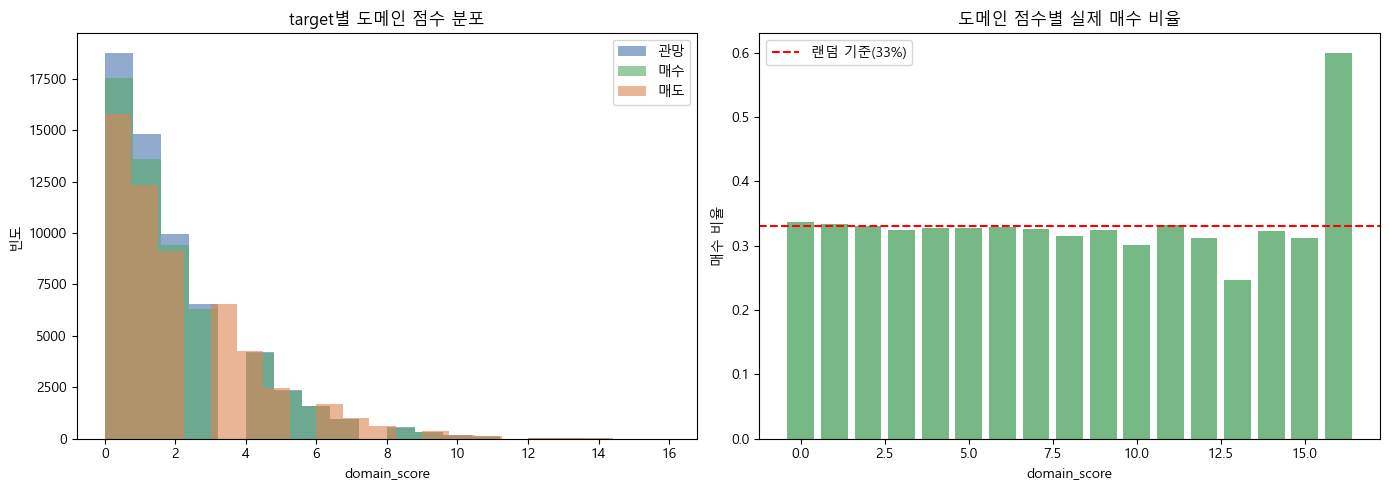

In [5]:
# 3-2
# 도메인 점수 시각화
colors = ['#4C72B0', '#55A868', '#DD8452']  # 추가

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
for t, label, color in zip([0,1,2], ['관망','매수','매도'], colors):
    axes[0].hist(df[df['target']==t]['domain_score'],
                 bins=20, alpha=0.6, label=label, color=color)
axes[0].set_title('target별 도메인 점수 분포')
axes[0].set_xlabel('domain_score')
axes[0].set_ylabel('빈도')
axes[0].legend()

# 점수별 매수 비율
score_buy_rate = df.groupby('domain_score').apply(
    lambda x: (x['target'] == 1).mean()
).reset_index()
score_buy_rate.columns = ['score', 'buy_rate']

axes[1].bar(score_buy_rate['score'], score_buy_rate['buy_rate'],
            color='#55A868', alpha=0.8)
axes[1].axhline(0.33, color='red', linestyle='--', label='랜덤 기준(33%)')
axes[1].set_title('도메인 점수별 실제 매수 비율')
axes[1].set_xlabel('domain_score')
axes[1].set_ylabel('매수 비율')
axes[1].legend()

plt.tight_layout()
plt.show()

In [6]:
# feature_cols에 domain_score 추가
feature_cols = [c for c in df.columns if c not in exclude_cols]
print(f'총 피처 수 (domain_score 포함): {len(feature_cols)}')

총 피처 수 (domain_score 포함): 90


In [7]:
# 셀 4 - 결측치 확인 및 처리
print('[결측치 확인]')
null_counts = df[feature_cols].isnull().sum()
print(null_counts[null_counts > 0])

df[feature_cols] = df[feature_cols].fillna(method='ffill').fillna(0)

print(f'\n결측치 처리 후: {df[feature_cols].isnull().sum().sum()}개')

[결측치 확인]
Series([], dtype: int64)

결측치 처리 후: 0개


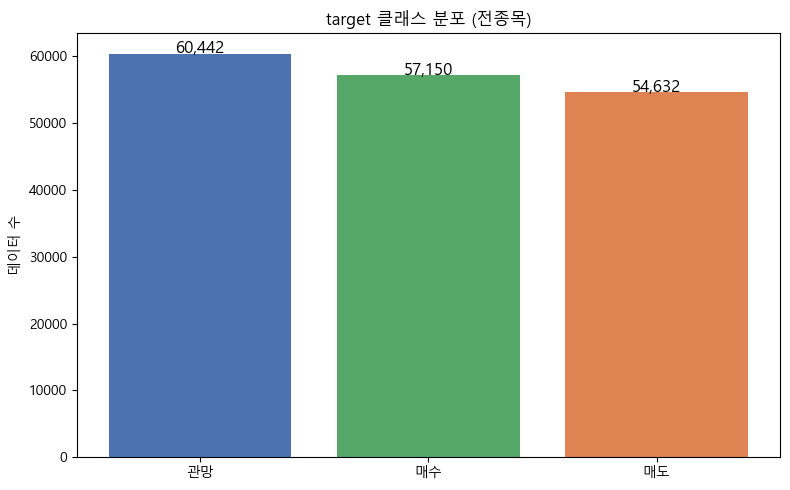

In [8]:
# 셀 5 - target 분포 시각화
target_map = {0: '관망', 1: '매수', 2: '매도'}
colors = ['#4C72B0', '#55A868', '#DD8452']

target_counts = df['target'].map(target_map).value_counts()

plt.figure(figsize=(8, 5))
bars = plt.bar(target_counts.index, target_counts.values, color=colors)
for bar, val in zip(bars, target_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{val:,}', ha='center', fontsize=12)
plt.title('target 클래스 분포 (전종목)')
plt.ylabel('데이터 수')
plt.tight_layout()
plt.show()

In [27]:
print('pred 분포:')
print(df_bt['pred'].value_counts())

print('\ndomain_score 분포:')
print(df_bt['domain_score'].value_counts().sort_index())

print('\npred==1 AND domain_score>=1:')
print(((df_bt['pred'] == 1) & (df_bt['domain_score'] >= 1)).sum())

print('\npred==1 AND pred_proba_buy>=0.5:')
print(((df_bt['pred'] == 1) & (df_bt['pred_proba_buy'] >= 0.5)).sum())

print('\npred==1 AND pred_proba_buy>=0.5 AND domain_score>=1:')
print(((df_bt['pred'] == 1) & (df_bt['pred_proba_buy'] >= 0.5) & (df_bt['domain_score'] >= 1)).sum())

pred 분포:
pred
1    13448
2    12298
0    10154
Name: count, dtype: int64

domain_score 분포:
domain_score
0     10117
1      8259
2      6248
3      4151
4      2797
5      1576
6      1200
7       714
8       389
9       214
10      112
11       70
12       21
13       19
14       11
15        1
16        1
Name: count, dtype: int64

pred==1 AND domain_score>=1:
8718

pred==1 AND pred_proba_buy>=0.5:
0

pred==1 AND pred_proba_buy>=0.5 AND domain_score>=1:
0


In [28]:
proba = model.predict_proba(X_test_scaled)
print(f'predict_proba shape: {proba.shape}')
print(f'컬럼 순서 (클래스): {model.classes_}')
print(f'\n확률 샘플 5개:')
print(proba[:5])
print(f'\npred 샘플 5개:')
print(y_pred[:5])
print(f'\n매수(pred==1) 샘플의 확률 분포:')
buy_mask = y_pred == 1
print(pd.DataFrame(proba[buy_mask], columns=['관망확률', '매수확률', '매도확률']).describe())

predict_proba shape: (35900, 3)
컬럼 순서 (클래스): [0 1 2]

확률 샘플 5개:
[[0.32283202 0.33835295 0.33881503]
 [0.32310128 0.3359958  0.34090292]
 [0.32443887 0.3411394  0.3344217 ]
 [0.32448047 0.33574274 0.33977675]
 [0.32382566 0.33688352 0.33929086]]

pred 샘플 5개:
[2 2 1 2 2]

매수(pred==1) 샘플의 확률 분포:
               관망확률          매수확률          매도확률
count  13448.000000  13448.000000  13448.000000
mean       0.325093      0.341829      0.333079
std        0.006904      0.005052      0.005159
min        0.303439      0.333393      0.315368
25%        0.321550      0.338164      0.330197
50%        0.326378      0.340790      0.332957
75%        0.330282      0.344612      0.336261
max        0.339665      0.368269      0.346564


In [26]:
# 셀 6
print('domain_score' in df_test.columns)
print(df_test['domain_score'].value_counts().sort_index() if 'domain_score' in df_test.columns else '없음')

# 반드시 분리 먼저, SMOTE는 X_train에만 적용
dates = df['date'].sort_values().unique()
split_idx  = int(len(dates) * 0.8)
split_date = dates[split_idx]

df_train = df[df['date'] < split_date].copy()
df_test  = df[df['date'] >= split_date].copy()

print(f'학습 기간: {df_train["date"].min()} ~ {df_train["date"].max()}')
print(f'테스트 기간: {df_test["date"].min()} ~ {df_test["date"].max()}')
print(f'학습 데이터: {df_train.shape}')
print(f'테스트 데이터: {df_test.shape}')

True
domain_score
0     10117
1      8259
2      6248
3      4151
4      2797
5      1576
6      1200
7       714
8       389
9       214
10      112
11       70
12       21
13       19
14       11
15        1
16        1
Name: count, dtype: int64
학습 기간: 2021-12-10 00:00:00 ~ 2025-07-22 00:00:00
테스트 기간: 2025-07-23 00:00:00 ~ 2026-06-15 00:00:00
학습 데이터: (136324, 94)
테스트 데이터: (35900, 94)


In [10]:
# 셀 7 - X, y 분리 + 스케일링
X_train = df_train[feature_cols]
y_train = df_train['target']
X_test  = df_test[feature_cols]
y_test  = df_test['target']

# domain_score 기반 샘플 가중치 (점수 높을수록 더 중요하게 학습)
base_weight = 1.0
score_col   = df_train['domain_score'].values
sample_weight_train = base_weight + score_col * 0.5

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=feature_cols)

print(f'X_train: {X_train_scaled.shape}')
print(f'X_test:  {X_test_scaled.shape}')
print(f'\n학습 target 분포:\n{y_train.value_counts()}')
print(f'\n샘플 가중치 분포:\n{pd.Series(sample_weight_train).describe()}')

X_train: (136324, 90)
X_test:  (35900, 90)

학습 target 분포:
target
0    49440
1    43709
2    43175
Name: count, dtype: int64

샘플 가중치 분포:
count    136324.000000
mean          1.937891
std           1.031742
min           1.000000
25%           1.000000
50%           1.500000
75%           2.500000
max           9.000000
dtype: float64


In [11]:
# 셀 8 - 클래스 불균형 처리 (SMOTE)
print('[SMOTE 적용 전]')
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

# SMOTE로 생성된 샘플은 기본 가중치 1.0 부여
# 원본 샘플 인덱스만큼은 domain_score 가중치 유지
n_original = len(X_train_scaled)
n_resampled = len(X_train_res)

sample_weight_res = np.ones(n_resampled)
sample_weight_res[:n_original] = sample_weight_train  # 원본만 가중치 적용

print('\n[SMOTE 적용 후]')
print(pd.Series(y_train_res).value_counts())
print(f'\n가중치 적용 샘플: {n_original}개 / 전체: {n_resampled}개')

[SMOTE 적용 전]
target
0    49440
1    43709
2    43175
Name: count, dtype: int64

[SMOTE 적용 후]
target
1    49440
0    49440
2    49440
Name: count, dtype: int64

가중치 적용 샘플: 136324개 / 전체: 148320개


In [12]:
# 셀 9 - XGBoost 모델 학습
model = XGBClassifier(
    n_estimators=2000,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.6,
    colsample_bytree=0.6,
    min_child_weight=20,
    reg_alpha=1.0,
    reg_lambda=5.0,
    eval_metric=['mlogloss', 'merror'],
    random_state=42,
    n_jobs=-1,
)

model.fit(
    X_train_res, y_train_res,
    sample_weight=sample_weight_res,  # 도메인 점수 가중치 적용
    eval_set=[
        (X_train_res, y_train_res),
        (X_test_scaled, y_test),
    ],
    early_stopping_rounds=200,
    verbose=100
)

print(f'최적 트리 수: {model.best_iteration}')
print('학습 완료')

[0]	validation_0-mlogloss:1.09836	validation_0-merror:0.59773	validation_1-mlogloss:1.09841	validation_1-merror:0.61593
[100]	validation_0-mlogloss:1.07867	validation_0-merror:0.56936	validation_1-mlogloss:1.08475	validation_1-merror:0.59604
[200]	validation_0-mlogloss:1.06764	validation_0-merror:0.56196	validation_1-mlogloss:1.07967	validation_1-merror:0.59596
[225]	validation_0-mlogloss:1.06548	validation_0-merror:0.55965	validation_1-mlogloss:1.07906	validation_1-merror:0.59735
최적 트리 수: 25
학습 완료


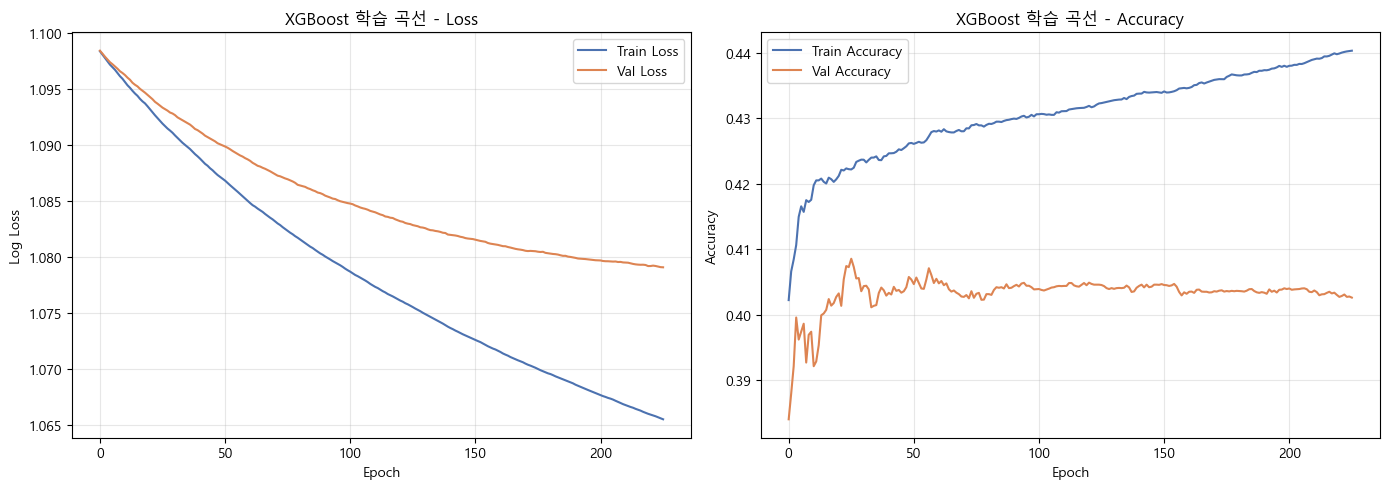

In [13]:
# 셀 10 - 학습 곡선
results = model.evals_result()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(results['validation_0']['mlogloss'], label='Train Loss', color='#4C72B0')
axes[0].plot(results['validation_1']['mlogloss'], label='Val Loss',   color='#DD8452')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Log Loss')
axes[0].set_title('XGBoost 학습 곡선 - Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
train_acc = [1 - e for e in results['validation_0']['merror']]
val_acc   = [1 - e for e in results['validation_1']['merror']]

axes[1].plot(train_acc, label='Train Accuracy', color='#4C72B0')
axes[1].plot(val_acc,   label='Val Accuracy',   color='#DD8452')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('XGBoost 학습 곡선 - Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
# 셀 11 - 모델 성능 평가
y_pred = model.predict(X_test_scaled)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'F1 Score (macro): {f1_score(y_test, y_pred, average="macro"):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['관망', '매수', '매도']))

Accuracy: 0.4086
F1 Score (macro): 0.4072

              precision    recall  f1-score   support

          관망       0.41      0.38      0.39     11002
          매수       0.43      0.43      0.43     13441
          매도       0.39      0.42      0.40     11457

    accuracy                           0.41     35900
   macro avg       0.41      0.41      0.41     35900
weighted avg       0.41      0.41      0.41     35900



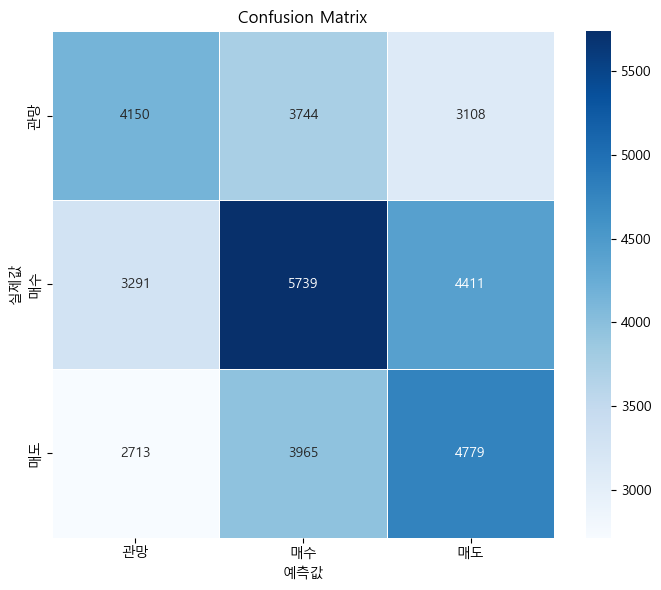

In [15]:
# 셀 12 - Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['관망', '매수', '매도'],
    yticklabels=['관망', '매수', '매도'],
    linewidths=0.5
)
plt.title('Confusion Matrix')
plt.xlabel('예측값')
plt.ylabel('실제값')
plt.tight_layout()
plt.show()

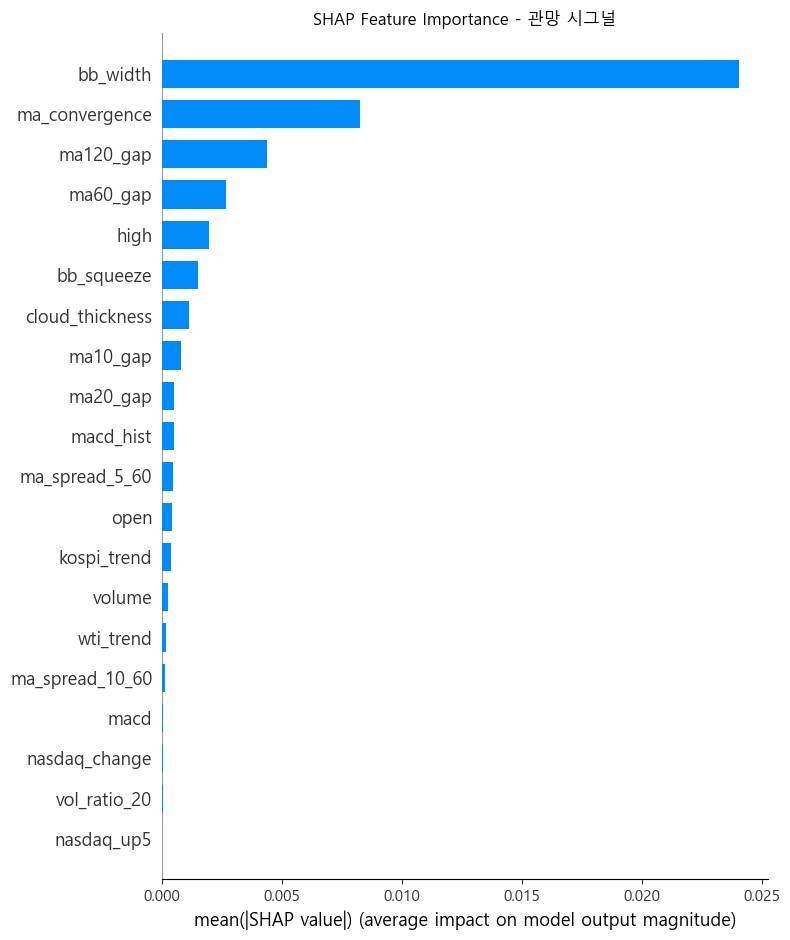

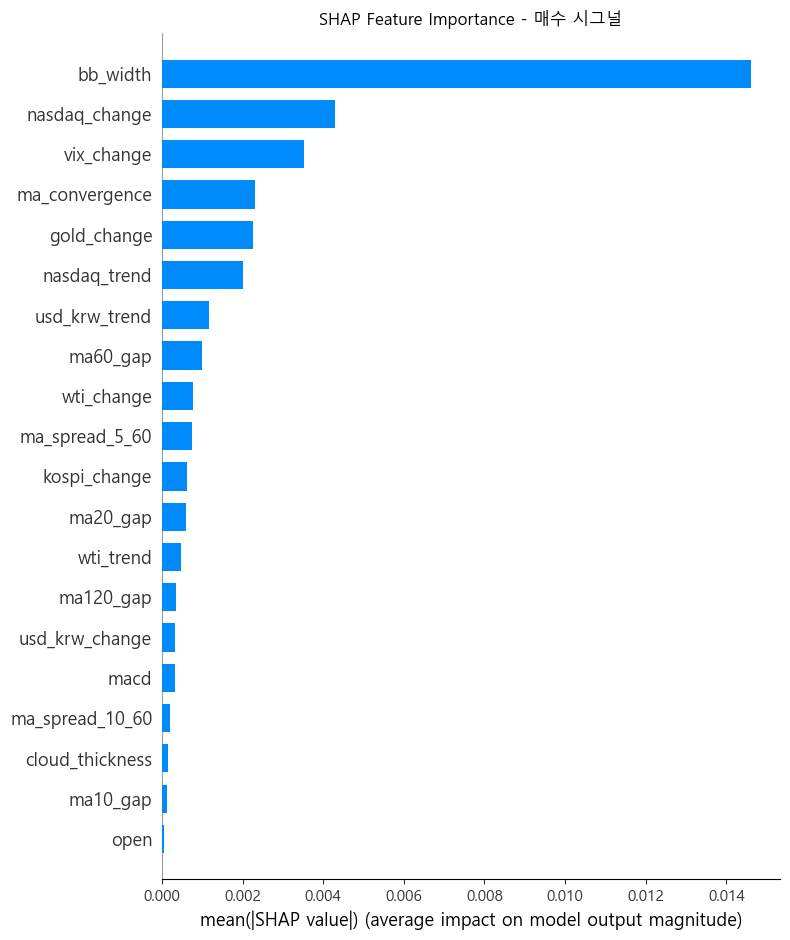

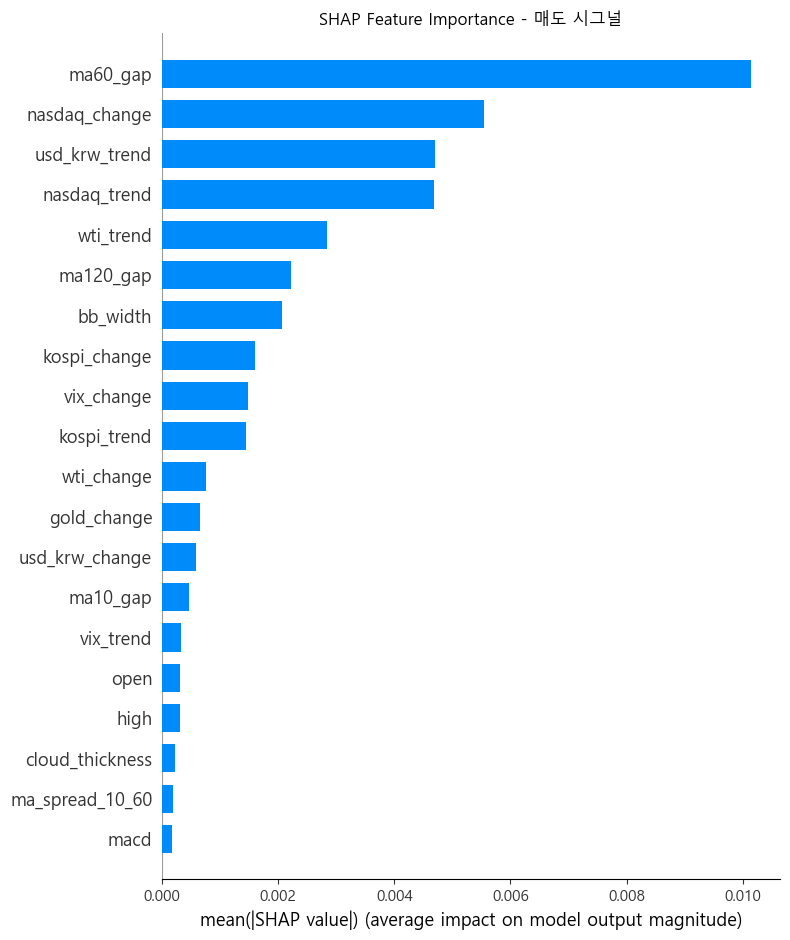

In [16]:
# 셀 13 - SHAP 피처 중요도 (클래스별)
# XGBoost 버전에 따라 shap_values 구조가 다름
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_scaled)

class_names = ['관망', '매수', '매도']

for i, name in enumerate(class_names):
    if isinstance(shap_values, list):
        sv = shap_values[i]
    else:
        sv = shap_values[:, :, i]
    plt.figure(figsize=(10, 8))
    shap.summary_plot(
        sv, X_test_scaled,
        plot_type='bar', max_display=20, show=False
    )
    plt.title(f'SHAP Feature Importance - {name} 시그널')
    plt.tight_layout()
    plt.show()

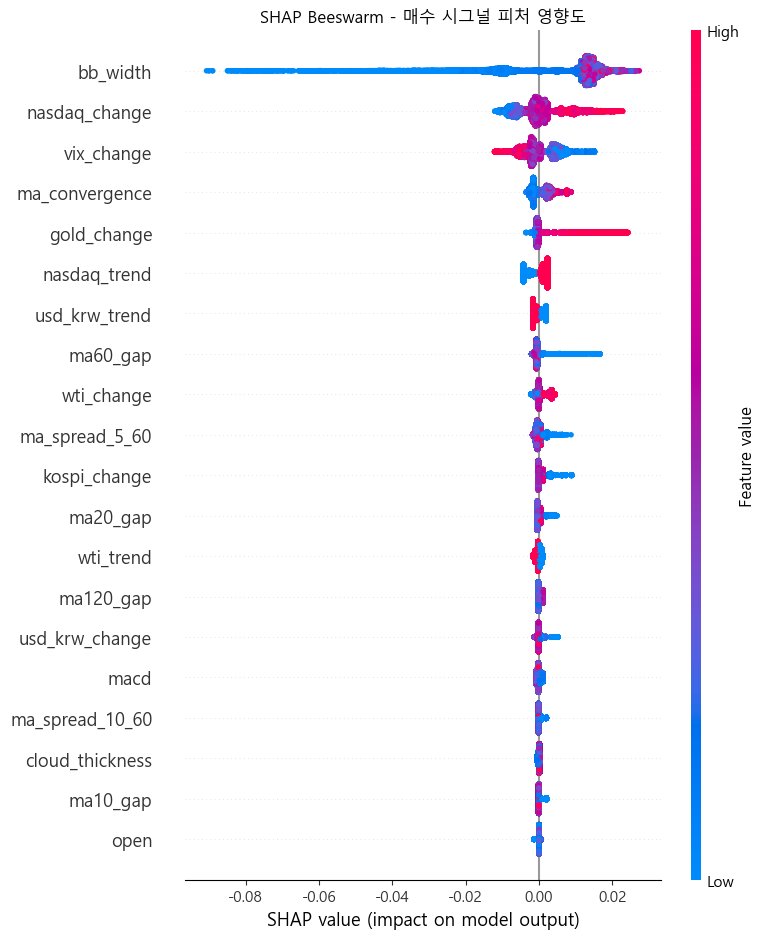

In [17]:
# 셀 14 - SHAP beeswarm (매수 시그널 기준)
if isinstance(shap_values, list):
    sv_buy = shap_values[1]
else:
    sv_buy = shap_values[:, :, 1]

plt.figure(figsize=(10, 10))
shap.summary_plot(
    sv_buy, X_test_scaled,
    max_display=20, show=False
)
plt.title('SHAP Beeswarm - 매수 시그널 피처 영향도')
plt.tight_layout()
plt.show()

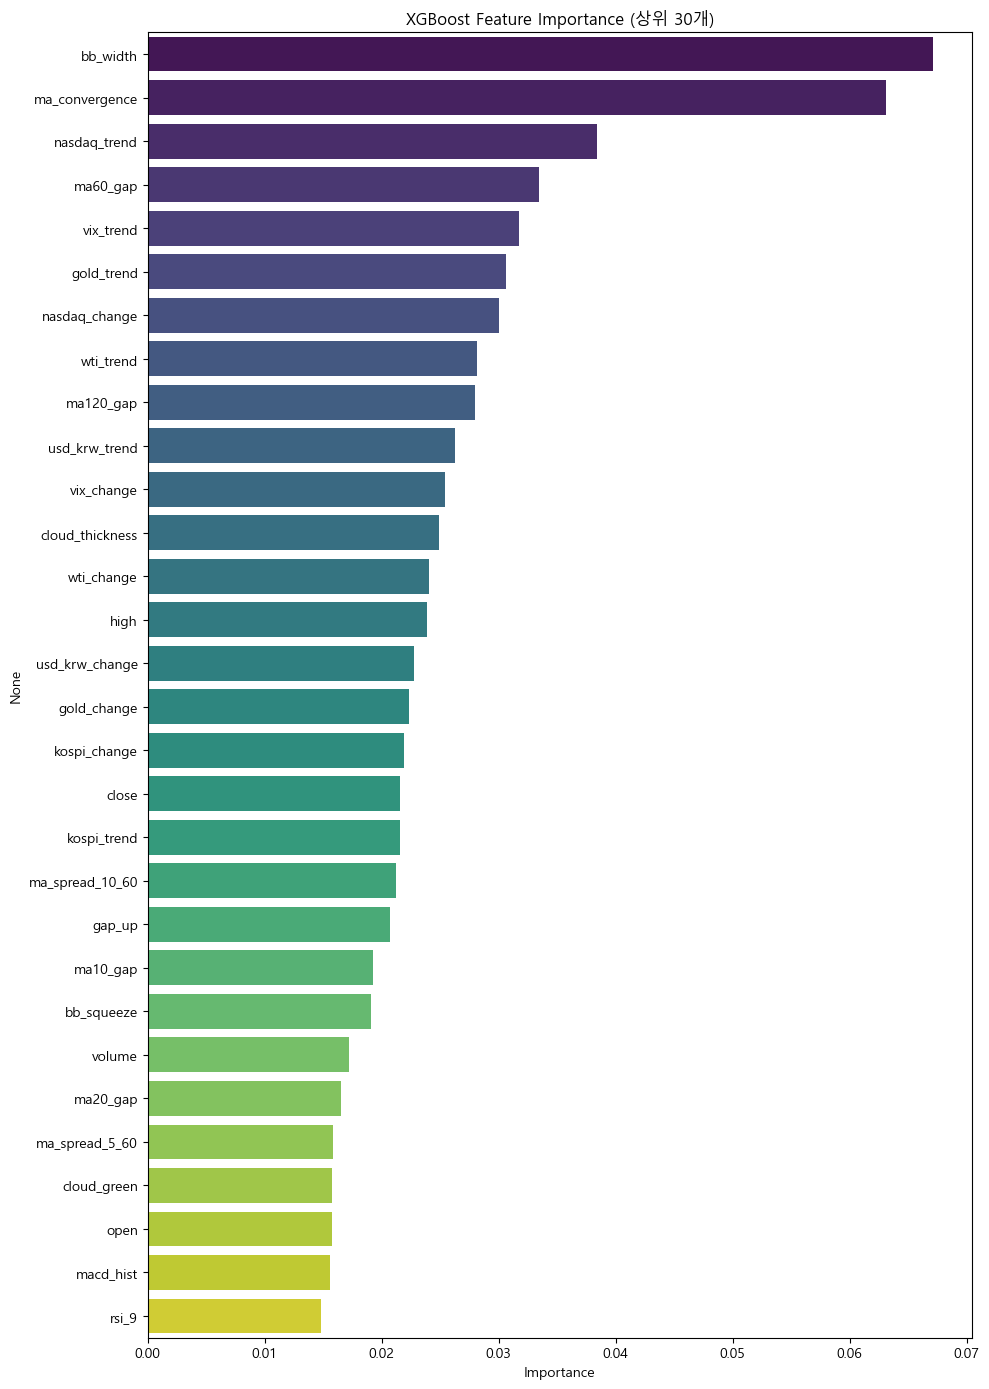

상위 20개:
bb_width           0.067098
ma_convergence     0.063132
nasdaq_trend       0.038441
ma60_gap           0.033461
vix_trend          0.031710
gold_trend         0.030633
nasdaq_change      0.030053
wti_trend          0.028131
ma120_gap          0.027999
usd_krw_trend      0.026254
vix_change         0.025397
cloud_thickness    0.024912
wti_change         0.024037
high               0.023896
usd_krw_change     0.022729
gold_change        0.022306
kospi_change       0.021928
close              0.021603
kospi_trend        0.021562
ma_spread_10_60    0.021227
dtype: float32


In [18]:
# 셀 15 - XGBoost Feature Importance
fi = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 14))
sns.barplot(x=fi.values[:30], y=fi.index[:30], palette='viridis')
plt.title('XGBoost Feature Importance (상위 30개)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print('상위 20개:')
print(fi.head(20))

In [29]:
# 셀 16 - 백테스팅
df_bt = df_test.copy().reset_index(drop=True)
df_bt['pred']           = y_pred

proba = model.predict_proba(X_test_scaled)
df_bt['proba_관망'] = proba[:, 0]
df_bt['proba_매수'] = proba[:, 1]
df_bt['proba_매도'] = proba[:, 2]

# 0.5 조건 제거 -> 매수 확률이 다른 클래스보다 높은 것만
df_bt['signal'] = (
    (df_bt['pred'] == 1) &
    (df_bt['proba_매수'] > df_bt['proba_관망']) &
    (df_bt['proba_매수'] > df_bt['proba_매도']) &
    (df_bt['domain_score'] >= 2)
).astype(int)

df_bt = df_bt.sort_values(['stock_code', 'date']).reset_index(drop=True)
df_bt['return_5d'] = df_bt.groupby('stock_code')['close'].transform(
    lambda x: x.shift(-5) / x - 1
)

df_signal = df_bt[df_bt['signal'] == 1].dropna(subset=['return_5d'])

print(f'총 매수 시그널: {len(df_signal)}건')
print(f'평균 수익률:    {df_signal["return_5d"].mean():.4f}')
print(f'승률:           {(df_signal["return_5d"] > 0).mean():.4f}')
print(f'최대 수익률:    {df_signal["return_5d"].max():.4f}')
print(f'최대 손실률:    {df_signal["return_5d"].min():.4f}')

총 매수 시그널: 5907건
평균 수익률:    0.0264
승률:           0.5686
최대 수익률:    0.9549
최대 손실률:    -0.3116


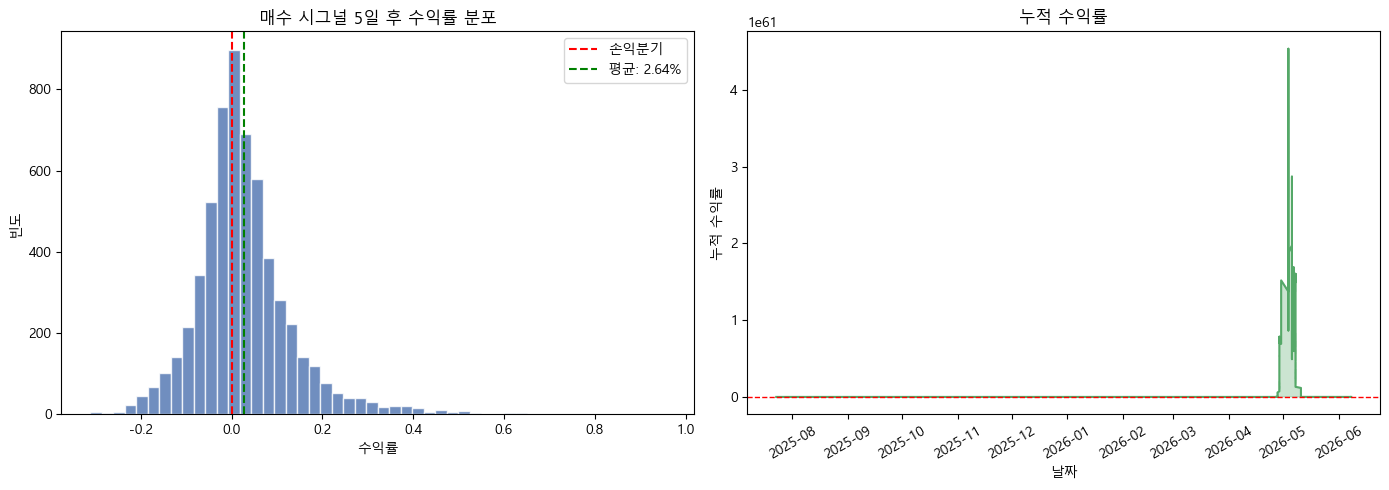

In [30]:
# 셀 17 - 수익률 분포 + 누적 수익률
df_cum = df_signal.sort_values('date').copy()
df_cum['cum_return'] = (1 + df_cum['return_5d']).cumprod() - 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_signal['return_5d'], bins=50, color='#4C72B0', alpha=0.8, edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='손익분기')
axes[0].axvline(df_signal['return_5d'].mean(), color='green', linestyle='--',
                linewidth=1.5, label=f'평균: {df_signal["return_5d"].mean():.2%}')
axes[0].set_title('매수 시그널 5일 후 수익률 분포')
axes[0].set_xlabel('수익률')
axes[0].set_ylabel('빈도')
axes[0].legend()

axes[1].plot(df_cum['date'], df_cum['cum_return'], color='#55A868', linewidth=1.5)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].fill_between(df_cum['date'], df_cum['cum_return'], 0,
                     where=df_cum['cum_return'] >= 0, alpha=0.3, color='#55A868')
axes[1].fill_between(df_cum['date'], df_cum['cum_return'], 0,
                     where=df_cum['cum_return'] < 0, alpha=0.3, color='#DD8452')
axes[1].set_title('누적 수익률')
axes[1].set_xlabel('날짜')
axes[1].set_ylabel('누적 수익률')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [31]:
# 셀 18 - MDD + 성과 요약
cum_returns = df_cum['cum_return'].values
rolling_max = np.maximum.accumulate(cum_returns)
mdd         = (cum_returns - rolling_max).min()

print('=== 백테스팅 성과 요약 ===')
print(f'총 시그널 수:   {len(df_signal)}건')
print(f'승률:           {(df_signal["return_5d"] > 0).mean():.2%}')
print(f'평균 수익률:    {df_signal["return_5d"].mean():.2%}')
print(f'누적 수익률:    {df_cum["cum_return"].iloc[-1]:.2%}')
print(f'MDD:            {mdd:.2%}')
print(f'+2% 이상 비율: {(df_signal["return_5d"] > 0.02).mean():.2%}')
print(f'-2% 이하 비율: {(df_signal["return_5d"] < -0.02).mean():.2%}')

=== 백테스팅 성과 요약 ===
총 시그널 수:   5907건
승률:           56.86%
평균 수익률:    2.64%
누적 수익률:    29869288446548836953991299956780626031846098441248702464.00%
MDD:            -4537449994543628643633085266943109114794256641891365775885729792.00%
+2% 이상 비율: 45.95%
-2% 이하 비율: 31.28%


상위 10개 종목:
 stock_code  stock_name  시그널수    평균수익률       승률     최대수익      최대손실
        500        가온전선    39 0.150402 0.641026 0.954939 -0.307921
       9150        삼성전기    40 0.115298 0.900000 0.742696 -0.187220
        660      SK하이닉스    45 0.107245 0.866667 0.311748 -0.116903
      11070       LG이노텍    35 0.103362 0.771429 0.375635 -0.110307
      66570        LG전자    35 0.102815 0.742857 0.638831 -0.086002
     103590        일진전기    45 0.102278 0.800000 0.493264 -0.158514
      10120 LS ELECTRIC    31 0.098259 0.612903 0.904274 -0.172524
       1740      SK네트웍스    20 0.097699 0.700000 0.535897 -0.153976
     402340       SK스퀘어    51 0.094799 0.803922 0.380228 -0.135294
     272210       한화시스템    46 0.093212 0.717391 0.600332 -0.119314


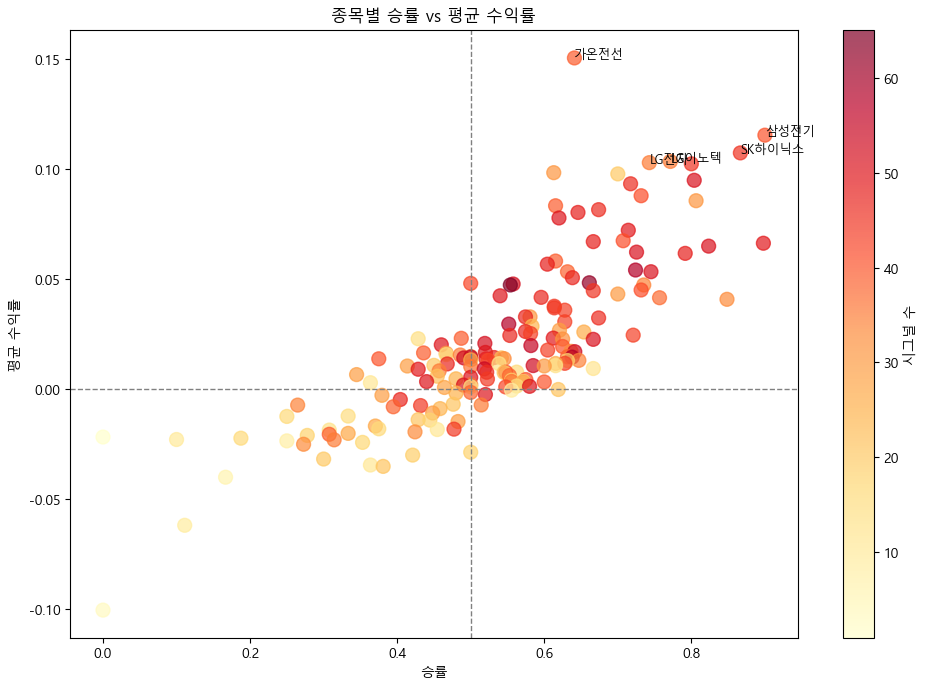

In [32]:
# 셀 19 - 종목별 성과 분석
stock_perf = df_signal.groupby(['stock_code', 'stock_name']).agg(
    시그널수=('return_5d', 'count'),
    평균수익률=('return_5d', 'mean'),
    승률=('return_5d', lambda x: (x > 0).mean()),
    최대수익=('return_5d', 'max'),
    최대손실=('return_5d', 'min'),
).reset_index().sort_values('평균수익률', ascending=False)

print('상위 10개 종목:')
print(stock_perf.head(10).to_string(index=False))

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    stock_perf['승률'], stock_perf['평균수익률'],
    c=stock_perf['시그널수'], cmap='YlOrRd', s=100, alpha=0.7
)
plt.colorbar(scatter, label='시그널 수')
plt.axhline(0,   color='gray', linestyle='--', linewidth=1)
plt.axvline(0.5, color='gray', linestyle='--', linewidth=1)
plt.xlabel('승률')
plt.ylabel('평균 수익률')
plt.title('종목별 승률 vs 평균 수익률')

for _, row in stock_perf.head(5).iterrows():
    plt.annotate(row['stock_name'], (row['승률'], row['평균수익률']), fontsize=9, ha='left')

plt.tight_layout()
plt.show()

                   피처  시그널수    평균수익률       승률
      macd_zero_cross   189 0.039096 0.671958
  uptrend_with_volume   765 0.036324 0.577778
double_bottom_confirm  1510 0.034097 0.576821
  ichi_cloud_breakout   502 0.029207 0.595618
    vol_surge_bullish   498 0.027102 0.538153
         rsi_macd_buy  2814 0.025286 0.554016
         ma60_support   680 0.025203 0.570588
           bb_squeeze  1247 0.024519 0.600642
          rsi_cooling   572 0.011094 0.487762
convergence_vol_surge    47 0.003070 0.446809


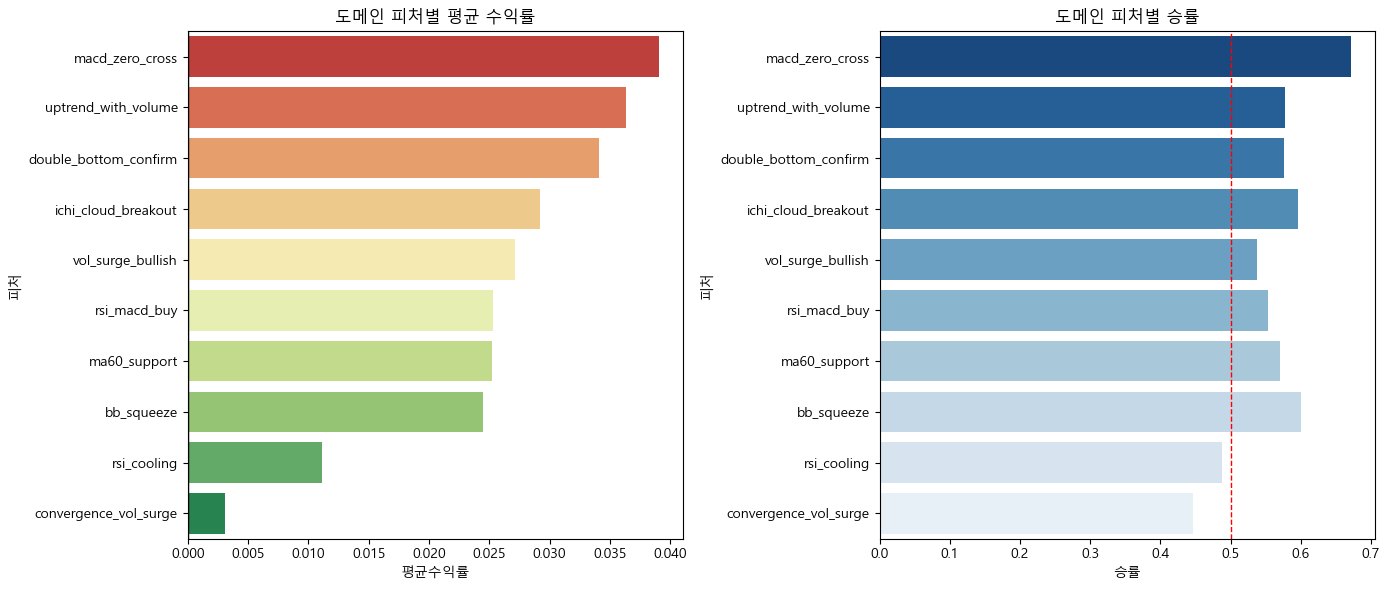

In [33]:
# 셀 20 - 도메인 파생변수 유효성 검증
domain_features = [
    'ma_convergence', 'uptrend_with_volume', 'ma60_support',
    'rsi_cooling', 'bb_squeeze', 'ichi_cloud_breakout',
    'macd_zero_cross', 'double_bottom_confirm',
    'rsi_macd_buy', 'vol_surge_bullish', 'convergence_vol_surge'
]
domain_features = [f for f in domain_features if f in df_bt.columns]

results_list = []
for feat in domain_features:
    mask = (df_bt['signal'] == 1) & (df_bt[feat] == 1)
    sub  = df_bt[mask].dropna(subset=['return_5d'])
    if len(sub) < 5:
        continue
    results_list.append({
        '피처':       feat,
        '시그널수':   len(sub),
        '평균수익률': sub['return_5d'].mean(),
        '승률':       (sub['return_5d'] > 0).mean(),
    })

df_domain_perf = pd.DataFrame(results_list).sort_values('평균수익률', ascending=False)
print(df_domain_perf.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(data=df_domain_perf, x='평균수익률', y='피처', palette='RdYlGn', ax=axes[0])
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('도메인 피처별 평균 수익률')

sns.barplot(data=df_domain_perf, x='승률', y='피처', palette='Blues_r', ax=axes[1])
axes[1].axvline(0.5, color='red', linestyle='--', linewidth=1)
axes[1].set_title('도메인 피처별 승률')

plt.tight_layout()
plt.show()

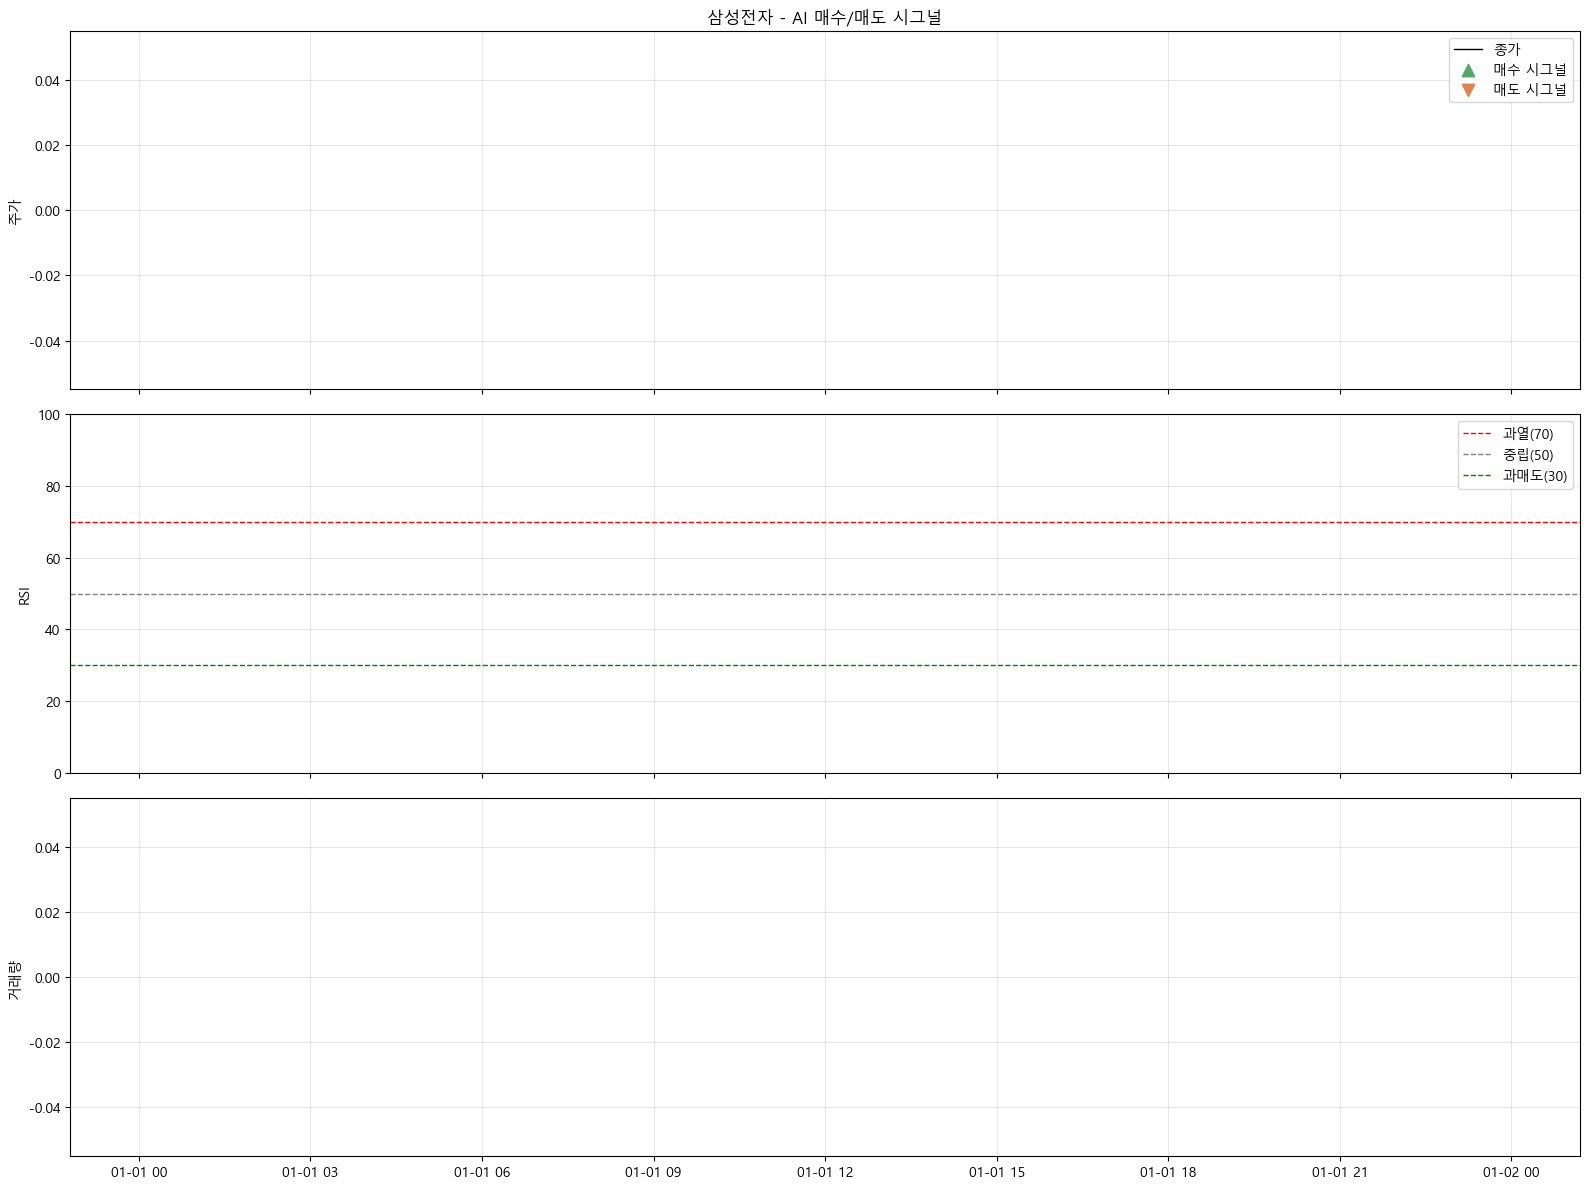

In [34]:
# 셀 21 - 삼성전자 시그널 차트 시각화
df_ss = df_bt[df_bt['stock_code'] == '005930'].sort_values('date').copy()

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# 차트 1 - 종가 + 시그널
axes[0].plot(df_ss['date'], df_ss['close'], color='black', linewidth=1, label='종가')
buy_mask  = df_ss['pred'] == 1
sell_mask = df_ss['pred'] == 2
axes[0].scatter(df_ss[buy_mask]['date'],  df_ss[buy_mask]['close'],
                color='#55A868', marker='^', s=80, zorder=5, label='매수 시그널')
axes[0].scatter(df_ss[sell_mask]['date'], df_ss[sell_mask]['close'],
                color='#DD8452', marker='v', s=80, zorder=5, label='매도 시그널')
axes[0].set_title('삼성전자 - AI 매수/매도 시그널')
axes[0].set_ylabel('주가')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 차트 2 - RSI
axes[1].plot(df_ss['date'], df_ss['rsi_9'], color='purple', linewidth=1)
axes[1].axhline(70, color='red',   linestyle='--', linewidth=1, label='과열(70)')
axes[1].axhline(50, color='gray',  linestyle='--', linewidth=1, label='중립(50)')
axes[1].axhline(30, color='green', linestyle='--', linewidth=1, label='과매도(30)')
axes[1].set_ylabel('RSI')
axes[1].set_ylim(0, 100)
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

# 차트 3 - 거래량
vol_colors = ['#55A868' if c > o else '#DD8452'
              for c, o in zip(df_ss['close'], df_ss['open'])]
axes[2].bar(df_ss['date'], df_ss['volume'], color=vol_colors, width=1, alpha=0.7)
axes[2].set_ylabel('거래량')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
# 셀 22 - 모델 저장
joblib.dump(model,  'xgb_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print('모델 저장 완료: xgb_model.pkl / scaler.pkl')

모델 저장 완료: xgb_model.pkl / scaler.pkl
